# PROCESS MINING PROJECT: Providing recommendations

This Jupyter Notebook implements a predictive and prescriptive process monitoring approach using decision trees with boolean encoding. It trains and evaluates a model on prefix traces of the Production log to predict fast or slow outcomes. For negatively predicted cases, it extracts actionable recommendations from the decision tree and evaluates their effectiveness using a dedicated metric, comparing results across different prefix lengths.


# STEP 0: Importing Libraries
Imports all required libraries: pm4py for log handling, scikit-learn for the decision tree, and pandas/numpy/matplotlib for data processing and visualization.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

from src.preprocessing import (
    import_log,
    create_prefixes_log,
    get_activity_names,
    boolean_encode
)
from src.recommendations import (
    extract_recommendations,
    print_recommendations
)

print("Libraries successfully loaded.")

Libraries successfully loaded.


# STEP 1: Loading the Logs
Loads the training (0–80%) and testing (80–100%) XES event logs from disk and prints basic trace statistics.

In [3]:
# Path to file XES 
TRAIN_LOG_PATH = "../Production_avg_dur_training_0-80.xes"
TEST_LOG_PATH = "../Production_avg_dur_testing_80-100.xes"

import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import import_log

# Load the training log
print("Loading training log")
train_log = import_log(TRAIN_LOG_PATH)
print(f"✓ Training log loaded: {len(train_log)} traces\n")

# Load the test log
print("Loading test log")
test_log = import_log(TEST_LOG_PATH)
print(f"✓ Test log loaded: {len(test_log)} traces")


Loading training log


parsing log, completed traces ::   0%|          | 0/177 [00:00<?, ?it/s]

✓ Training log loaded: 177 traces

Loading test log


parsing log, completed traces ::   0%|          | 0/43 [00:00<?, ?it/s]

✓ Test log loaded: 43 traces


In [4]:
example_trace = train_log[0]

print(f"Trace ID: {example_trace.attributes.get('concept:name')}")
print(f"Label: {example_trace.attributes.get('label')}")
print(f"Number of events: {len(example_trace)}\n")

print("First 5 activities:")
for i, event in enumerate(example_trace[:5]):
    print(f"  {i+1}. {event['concept:name']}")

Trace ID: Case100
Label: false
Number of events: 14

First 5 activities:
  1. Turning & Milling - Machine 8
  2. Turning & Milling - Machine 8
  3. Turning & Milling - Machine 8
  4. Turning & Milling - Machine 8
  5. Turning & Milling Q.C.


# STEP 2: Prefix Generation
Truncates each trace to the chosen prefix length. Traces shorter than the prefix are padded with a dummy event to ensure uniform length.

In [5]:
# Choose the prefix lengths to generate
lengths = [5, 11]
PREFIX_LENGTH = lengths[1]

print(f"Creating prefixes of length {PREFIX_LENGTH}\n")

# Create training prefixes with padding
train_prefixes = create_prefixes_log(train_log, PREFIX_LENGTH, use_padding=True)
print(f"Training prefixes: {len(train_prefixes)} traces")

# Check that all traces have the expected length
train_lengths = [len(trace) for trace in train_prefixes]
print(f"  - Minimum length: {min(train_lengths)}")
print(f"  - Maximum length: {max(train_lengths)}")
print(f"  - All traces have length {PREFIX_LENGTH}: {all(l == PREFIX_LENGTH for l in train_lengths)}")

# Create testing prefixes with padding
test_prefixes = create_prefixes_log(test_log, PREFIX_LENGTH, use_padding=True)
print(f"Test prefixes: {len(test_prefixes)} traces")

# Check that all traces have the expected length
test_lengths = [len(trace) for trace in test_prefixes]
print(f"  - Minimum length: {min(test_lengths)}")
print(f"  - Maximum length: {max(test_lengths)}")
print(f"  - All traces have length {PREFIX_LENGTH}: {all(l == PREFIX_LENGTH for l in test_lengths)}")

Creating prefixes of length 11

Training prefixes: 177 traces
  - Minimum length: 11
  - Maximum length: 11
  - All traces have length 11: True
Test prefixes: 43 traces
  - Minimum length: 11
  - Maximum length: 11
  - All traces have length 11: True


In [6]:
# Verify that padding has been applied correctly
print("Checking padding application:\n")

# Find an original trace shorter than PREFIX_LENGTH
example_short_trace_idx = None
for i, trace in enumerate(train_log):
    if len(trace) < PREFIX_LENGTH:
        example_short_trace_idx = i
        break

if example_short_trace_idx is not None:
    original_trace = train_log[example_short_trace_idx]
    padded_trace = train_prefixes[example_short_trace_idx]
    
    print("Example of a trace with padding applied:")
    print(f"  Trace ID: {original_trace.attributes.get('concept:name')}")
    print(f"  Original length: {len(original_trace)} events")
    print(f"  Length after padding: {len(padded_trace)} events")
    
    print("Events in the padded prefix:")
    for i, event in enumerate(padded_trace):
        event_name = event['concept:name']
        marker = " [PADDING]" if event_name == 'PADDING' else ""
        print(f"  {i+1}. {event_name}{marker}")
else:
    print("All traces in the training log are >= PREFIX_LENGTH")
    
    print(f"\nOriginal trace: {len(train_log[0])} events")
    print(f"Prefix: {len(train_prefixes[0])} events")
    
    print("\nPrefix of the first trace:")
    for i, event in enumerate(train_prefixes[0]):
        print(f"  {i+1}. {event['concept:name']}")

Checking padding application:

Example of a trace with padding applied:
  Trace ID: Case177
  Original length: 6 events
  Length after padding: 11 events
Events in the padded prefix:
  1. Lapping - Machine 1
  2. Round Grinding - Machine 2
  3. Round Grinding - Machine 2
  4. Round Grinding - Machine 2
  5. Final Inspection Q.C.
  6. Final Inspection Q.C.
  7. PADDING [PADDING]
  8. PADDING [PADDING]
  9. PADDING [PADDING]
  10. PADDING [PADDING]
  11. PADDING [PADDING]


# STEP 3: Activity Name Extraction
Collects all unique activity names from the training log; these will become the binary feature columns after encoding.

In [7]:
activity_names = get_activity_names(train_log)

print(f"Found {len(activity_names)} unique activities:")
for i, activity in enumerate(activity_names, 1):
    print(f"  {i}. {activity}")

Found 26 unique activities:
  1. Turning & Milling - Machine 8
  2. Turning & Milling Q.C.
  3. Laser Marking - Machine 7
  4. Flat Grinding - Machine 11
  5. Lapping - Machine 1
  6. Round Grinding - Machine 3
  7. other
  8. Final Inspection Q.C.
  9. Packing
  10. Round Grinding - Machine 2
  11. Turning & Milling - Machine 5
  12. Turning & Milling - Machine 10
  13. Round Grinding - Q.C.
  14. Turning - Machine 9
  15. Turning Q.C.
  16. Round Grinding - Manual
  17. Turning & Milling - Machine 6
  18. Turning - Machine 8
  19. Turning & Milling - Machine 4
  20. Round Grinding - Machine 12
  21. Grinding Rework - Machine 27
  22. Turning & Milling - Machine 9
  23. Milling - Machine 16
  24. Milling - Machine 14
  25. Wire Cut - Machine 13
  26. Turn & Mill. & Screw Assem - Machine 10


# STEP 4: Boolean Encoding
Encodes each prefix trace as a binary feature vector: 1 if an activity appears in the prefix, 0 otherwise. The label column stores the ground-truth class (true = fast, false = slow).

In [8]:
import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import boolean_encode

print("Boolean encoding of logs \n")

# Encode training set
train_encoded = boolean_encode(train_prefixes, activity_names)
print(f"Training encoded: {train_encoded.shape}")
print(f"Columns: {list(train_encoded.columns[:5])} ... {list(train_encoded.columns[-3:])}\n")

# Encode test set
test_encoded = boolean_encode(test_prefixes, activity_names)
print(f"Test encoded: {test_encoded.shape}")

Boolean encoding of logs 

Training encoded: (177, 29)
Columns: ['trace_id', 'prefix_length', 'Turning & Milling - Machine 8', 'Turning & Milling Q.C.', 'Laser Marking - Machine 7'] ... ['Wire Cut - Machine 13', 'Turn & Mill. & Screw Assem - Machine 10', 'label']

Test encoded: (43, 29)


In [9]:
# Analysis of the dataframe – all activities for the first 3 traces
print(f"# Unique activities in the log: {len(activity_names)}")
print("\nFirst 3 encoded traces showing all activities:")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(train_encoded.iloc[:3])

# Unique activities in the log: 26

First 3 encoded traces showing all activities:


,trace_id,prefix_length,Turning & Milling - Machine 8,Turning & Milling Q.C.,Laser Marking - Machine 7,Flat Grinding - Machine 11,Lapping - Machine 1,Round Grinding - Machine 3,other,Final Inspection Q.C.,Packing,Round Grinding - Machine 2,Turning & Milling - Machine 5,Turning & Milling - Machine 10,Round Grinding - Q.C.,Turning - Machine 9,Turning Q.C.,Round Grinding - Manual,Turning & Milling - Machine 6,Turning - Machine 8,Turning & Milling - Machine 4,Round Grinding - Machine 12,Grinding Rework - Machine 27,Turning & Milling - Machine 9,Milling - Machine 16,Milling - Machine 14,Wire Cut - Machine 13,Turn & Mill. & Screw Assem - Machine 10,label
0,Case100,11,True,True,True,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,false
1,Case177,11,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,false
2,Case142,11,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,true


# STEP 5: Training the Decision Tree
Selects the best hyperparameters via 5-fold GridSearchCV (216 combinations, F1-score scorer), then trains the final Decision Tree classifier on the full training set.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, f1_score

# Define the hyperparameter search space
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

total_combinations = (
    len(param_grid['max_depth']) *
    len(param_grid['criterion']) *
    len(param_grid['max_features']) *
    len(param_grid['min_samples_split']) *
    len(param_grid['min_samples_leaf'])
)

print(f"Testing {total_combinations} parameter combinations\n")

# Prepare training data excluding prefix_length as in the main training
X_train_opt = train_encoded.drop(['trace_id', 'label', 'prefix_length'], axis=1)
y_train_opt = train_encoded['label']

# Custom scorer: F1 with pos_label='true' (consistent with string labels)
f1_true_scorer = make_scorer(f1_score, pos_label='true')

# GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring=f1_true_scorer,  # Optimize for F1-score with pos_label='true'
    n_jobs=-1,               # Use all available cores
    verbose=1
)

grid_search.fit(X_train_opt, y_train_opt)

print("Hyperparameter optimization results")
print("\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest F1-score (CV): {grid_search.best_score_:.4f}")

optimized_params = grid_search.best_params_
optimized_params['random_state'] = 42

Testing 216 parameter combinations

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Hyperparameter optimization results

Best parameters found:
  criterion: entropy
  max_depth: 2
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 2

Best F1-score (CV): 0.8222


In [11]:
# Choose which parameter set to use
USE_OPTIMIZED = True  # Set to True to use parameters optimized via GridSearchCV

if USE_OPTIMIZED and 'optimized_params' in locals():
    print("Using optimized parameters from GridSearchCV\n")
    params = optimized_params
else:
    print("Using manual parameters\n")
    # Reasonable default parameters
    params = {
        'max_depth': 3,
        'max_features': 20,
        'criterion': 'gini',  
        'random_state': 42
    }

print("Decision Tree Parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")


X_train = train_encoded.drop(['trace_id', 'label', 'prefix_length'], axis=1)
y_train = train_encoded['label']

X_test = test_encoded.drop(['trace_id', 'label', 'prefix_length'], axis=1)
y_test = test_encoded['label']  

feature_names = X_train.columns.tolist()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nTraining class distribution:")
print(f"  - Positive (true): {(y_train == 'true').sum()} ({(y_train == 'true').sum() / len(y_train) * 100:.1f}%)")
print(f"  - Negative (false): {(y_train == 'false').sum()} ({(y_train == 'false').sum() / len(y_train) * 100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  - Positive (true): {(y_test == 'true').sum()} ({(y_test == 'true').sum() / len(y_test) * 100:.1f}%)")
print(f"  - Negative (false): {(y_test == 'false').sum()} ({(y_test == 'false').sum() / len(y_test) * 100:.1f}%)")

# Check datasets
assert X_train.shape[0] == len(y_train), "Mismatch between X_train and y_train"
assert X_test.shape[0] == len(y_test), "Mismatch between X_test and y_test"
assert X_train.shape[1] == X_test.shape[1], "Number of features differs between train and test"
assert 'prefix_length' not in feature_names, "prefix_length should not be among features"



Using optimized parameters from GridSearchCV

Decision Tree Parameters:
  criterion: entropy
  max_depth: 2
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 2
  random_state: 42
X_train shape: (177, 26)
y_train shape: (177,)
X_test shape: (43, 26)
y_test shape: (43,)
Number of features: 26

Training class distribution:
  - Positive (true): 116 (65.5%)
  - Negative (false): 61 (34.5%)

Test class distribution:
  - Positive (true): 32 (74.4%)
  - Negative (false): 11 (25.6%)


In [12]:
# Train the Decision Tree
print("\nTraining Decision Tree")

clf = DecisionTreeClassifier(**params)

clf.fit(X_train, y_train)

print(f"  Tree depth: {clf.get_depth()}")
print(f"  Number of leaves: {clf.get_n_leaves()}")


Training Decision Tree
  Tree depth: 2
  Number of leaves: 4


# Decision Tree Visualization
Renders the trained tree as an annotated graph using Graphviz, showing split features, class proportions, and leaf predictions.

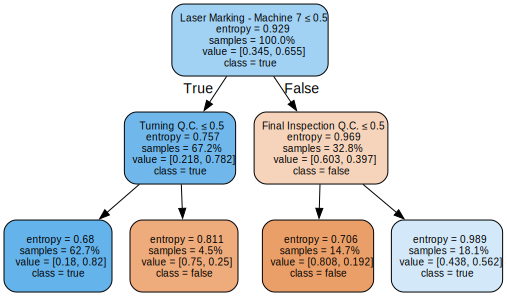

In [13]:
from sklearn.tree import export_graphviz
import graphviz
import html

# Escape HTML special characters in feature names
safe_feature_names = [html.escape(name) for name in feature_names]

dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=safe_feature_names,
    class_names=['false', 'true'],
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=True
)

dot_lines = dot_data.splitlines()
for i, line in enumerate(dot_lines):
    if line.strip().startswith("digraph Tree"):
        dot_lines.insert(i + 1, 'node [fontsize=10, width=1.5, height=1];')
        break

dot_data_fixed = "\n".join(dot_lines)

graph = graphviz.Source(dot_data_fixed, format='png')
graph

# STEP 6: Model Evaluation
Evaluates the trained tree on the test set, reporting accuracy, precision, recall and F1-score alongside the confusion matrix.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions on the test set
y_pred = clf.predict(X_test)

# Compute metrics 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='true')
recall = recall_score(y_test, y_pred, pos_label='true')
f1 = f1_score(y_test, y_pred, pos_label='true')

print("DECISION TREE PERFORMANCE")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

# Confusion matrix 
cm = confusion_matrix(y_test, y_pred, labels=['false', 'true'])
print("\nConfusion Matrix:")
print(f"                Pred Neg    Pred Pos")
print(f"Actual Neg (false)  {cm[0,0]:3d}         {cm[0,1]:3d}")
print(f"Actual Pos (true)   {cm[1,0]:3d}         {cm[1,1]:3d}")

# Detailed confusion metrics
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"\nConfusion Matrix Details:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

DECISION TREE PERFORMANCE
Accuracy:  0.814
Precision: 0.833
Recall:    0.938
F1-Score:  0.882

Confusion Matrix:
                Pred Neg    Pred Pos
Actual Neg (false)    5           6
Actual Pos (true)     2          30

Confusion Matrix Details:
  True Negatives (TN):  5
  False Positives (FP): 6
  False Negatives (FN): 2
  True Positives (TP):  30


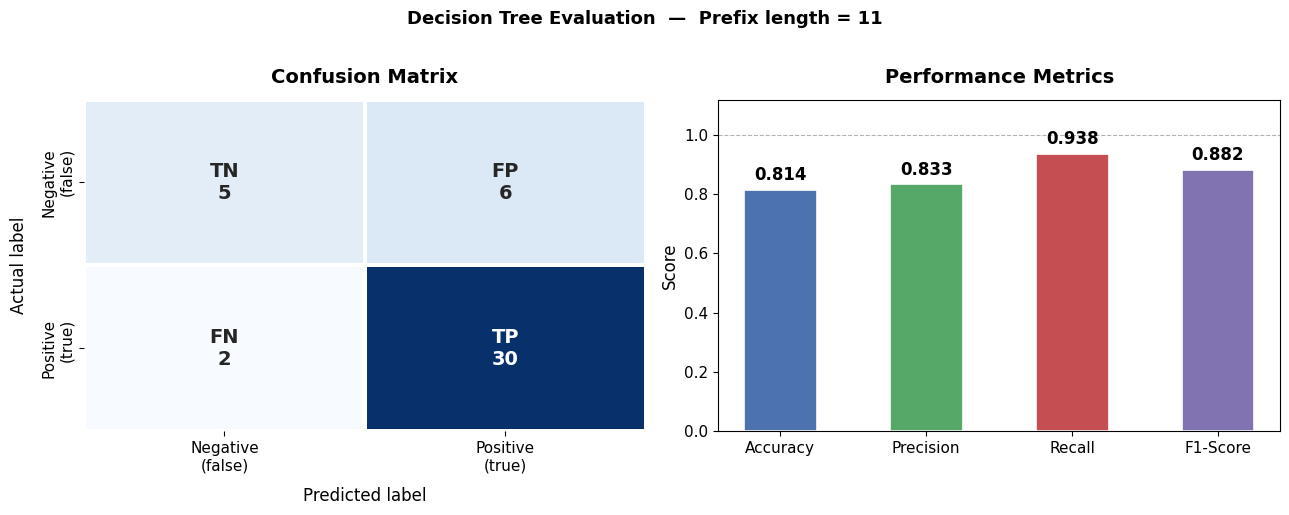

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Confusion matrix heatmap ──────────────────────────────────────────
labels = ['Negative\n(false)', 'Positive\n(true)']
annot = np.array([[f"TN\n{tn}", f"FP\n{fp}"],
                  [f"FN\n{fn}", f"TP\n{tp}"]])

# Colour map: correct predictions darker, errors lighter
colors = np.array([[tn, -fp], [-fn, tp]], dtype=float)

sns.heatmap(
    cm,
    ax=axes[0],
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1.5,
    linecolor='white',
    cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_xlabel('Predicted label', fontsize=12, labelpad=10)
axes[0].set_ylabel('Actual label', fontsize=12, labelpad=10)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
axes[0].tick_params(axis='both', labelsize=11)

# ── Right: Performance metrics bar chart ────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values  = [accuracy, precision, recall, f1]
colors_bar = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[1].bar(metrics, values, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.2)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold', pad=12)
axes[1].tick_params(axis='both', labelsize=11)
axes[1].axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.suptitle(f'Decision Tree Evaluation  —  Prefix length = {PREFIX_LENGTH}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
import importlib
import src.recommendations, src.tree_utils
importlib.reload(src.tree_utils)
importlib.reload(src.recommendations)
from src.recommendations import extract_recommendations, print_recommendations

# class_values: first element is the positive class, second is the negative class
class_values = ['true', 'false']

print(f"Test encoded shape: {test_encoded.shape}")
print(f"Class values: {class_values} (positive = '{class_values[0]}')")
print(f"Tree classes: {list(clf.classes_)}")

Test encoded shape: (43, 29)
Class values: ['true', 'false'] (positive = 'true')
Tree classes: ['false', 'true']


# STEP 7: Extract Recommendations
For each negatively predicted test trace, extracts actionable conditions from positive tree paths as a set of recommendations (activities to add or remove).

In [17]:
# extract_recommendations now predicts internally and uses class_values
recommendations = extract_recommendations(
    tree=clf,
    feature_names=feature_names,
    class_values=class_values,
    prefix_set=test_encoded
)

Found 2 positive paths in the tree

Summary:
  - Traces with positive prediction: 36
  - Traces with recommendations: 7
  - Negative traces without possible recommendations: 0


## STEP 8: Recommendation Analysis

Let us inspect which recommendations were generated.

In [18]:
# Filter only traces with actual recommendations (non-empty sets)
filtered_recommendations = {
    k: v for k, v in recommendations.items() if v is not None and len(v) > 0
}

print(f"\nTotal unique traces: {len(recommendations)}")
print(f"Traces with recommendations: {len(filtered_recommendations)}")
print(f"Traces without recommendations (positive or no path): {len(recommendations) - len(filtered_recommendations)}")


Total unique traces: 31
Traces with recommendations: 7
Traces without recommendations (positive or no path): 24


In [21]:
# Display some recommendations
print_recommendations(filtered_recommendations, max_display=10)

RECOMMENDATIONS EXTRACTED

[1] Trace with activities: {'other', 'Turning & Milling - Machine 4', 'Turning & Milling Q.C.', 'Laser Marking - Machine 7', 'Lapping - Machine 1', 'Round Grinding - Machine 3', 'Turning & Milling - Machine 5'}
Recommendations:
       • Add: Final Inspection Q.C.

[2] Trace with activities: {'Round Grinding - Machine 2', 'Turning & Milling Q.C.', 'Turning & Milling - Machine 8', 'Lapping - Machine 1', 'Laser Marking - Machine 7', 'Flat Grinding - Machine 11'}
Recommendations:
       • Add: Final Inspection Q.C.

[3] Trace with activities: {'other', 'Turning & Milling Q.C.', 'Laser Marking - Machine 7', 'Turning & Milling - Machine 5'}
Recommendations:
       • Add: Final Inspection Q.C.

[4] Trace with activities: {'Turning & Milling - Machine 9', 'Turning Q.C.'}
Recommendations:
       • Add: Final Inspection Q.C.
       • Add: Laser Marking - Machine 7

[5] Trace with activities: {'Turning Q.C.', 'Turning & Milling - Machine 5'}
Recommendations:
       • Ad

## STEP 9: Detailed Example

Let us pick a specific trace and inspect its recommendation in detail.

In [23]:
# Pick the first non-empty recommendation
example_trace_activities = None
example_recommendations = None

for activities, recs in filtered_recommendations.items():
    if recs and len(recs) > 0:
        example_trace_activities = activities
        example_recommendations = recs
        break

if example_trace_activities:
    print("DETAILED RECOMMENDATION EXAMPLE")
    print(f"\nCurrent trace activities:")
    for i, activity in enumerate(sorted(example_trace_activities), 1):
        print(f"   {i}. {activity}")
    
    print(f"\nThe system recommends:")
    for i, condition in enumerate(example_recommendations, 1):
        action = "ADD" if condition.value else "REMOVE"
        print(f"   {i}. {action}: '{condition.feature}'")
    
else:
    print("No recommendation with activities to add was found.")

DETAILED RECOMMENDATION EXAMPLE

Current trace activities:
   1. Lapping - Machine 1
   2. Laser Marking - Machine 7
   3. Round Grinding - Machine 3
   4. Turning & Milling - Machine 4
   5. Turning & Milling - Machine 5
   6. Turning & Milling Q.C.
   7. other

The system recommends:
   1. ADD: 'Final Inspection Q.C.'


# STEP 10: Evaluate Recommendations
Checks whether the recommended activities were actually followed in the full (non-truncated) test traces, building a TP/TN/FP/FN confusion matrix and computing the recommendation metric F_rec.

In [26]:
import importlib
import src.recommendations
importlib.reload(src.recommendations)
from src.recommendations import evaluate_recommendations

# Boolean encode the FULL test traces (not just prefixes) for evaluation
full_test_encoded = boolean_encode(test_log, activity_names)
print(f"Full test traces encoded: {full_test_encoded.shape}")
print(f"Prefix test traces:       {test_encoded.shape}")

# Build test_set dictionary as required by the assignment signature
test_set = {
    'tree': clf,
    'feature_names': feature_names,
    'class_values': class_values,
    'prefix_test_set': test_encoded,
    'full_test_set': full_test_encoded
}

# Evaluate recommendations — signature: evaluate_recommendations(test_set, recommendations)
eval_results = evaluate_recommendations(test_set, recommendations)

print("\n RECOMMENDATION EVALUATION")
print(f"\nTraces evaluated (negative predictions): {eval_results['evaluated']}")
print(f"\nConfusion Matrix (Recommendations):")
print(f"  True Positives  (TP): {eval_results['tp']}  — Rec followed, outcome positive")
print(f"  True Negatives  (TN): {eval_results['tn']}  — Rec NOT followed, outcome negative")
print(f"  False Positives (FP): {eval_results['fp']}  — Rec followed, outcome negative")
print(f"  False Negatives (FN): {eval_results['fn']}  — Rec NOT followed, outcome positive")
print(f"\nMetrics:")
print(f"  Accuracy:  {eval_results['accuracy']:.4f}")
print(f"  Precision: {eval_results['precision']:.4f}")
print(f"  Recall:    {eval_results['recall']:.4f}")

print(f"  F1-Score:  {eval_results['f1_score']:.4f}")

Full test traces encoded: (43, 29)
Prefix test traces:       (43, 29)

 RECOMMENDATION EVALUATION

Traces evaluated (negative predictions): 7

Confusion Matrix (Recommendations):
  True Positives  (TP): 1  — Rec followed, outcome positive
  True Negatives  (TN): 4  — Rec NOT followed, outcome negative
  False Positives (FP): 1  — Rec followed, outcome negative
  False Negatives (FN): 1  — Rec NOT followed, outcome positive

Metrics:
  Accuracy:  0.7143
  Precision: 0.5000
  Recall:    0.5000
  F1-Score:  0.5000


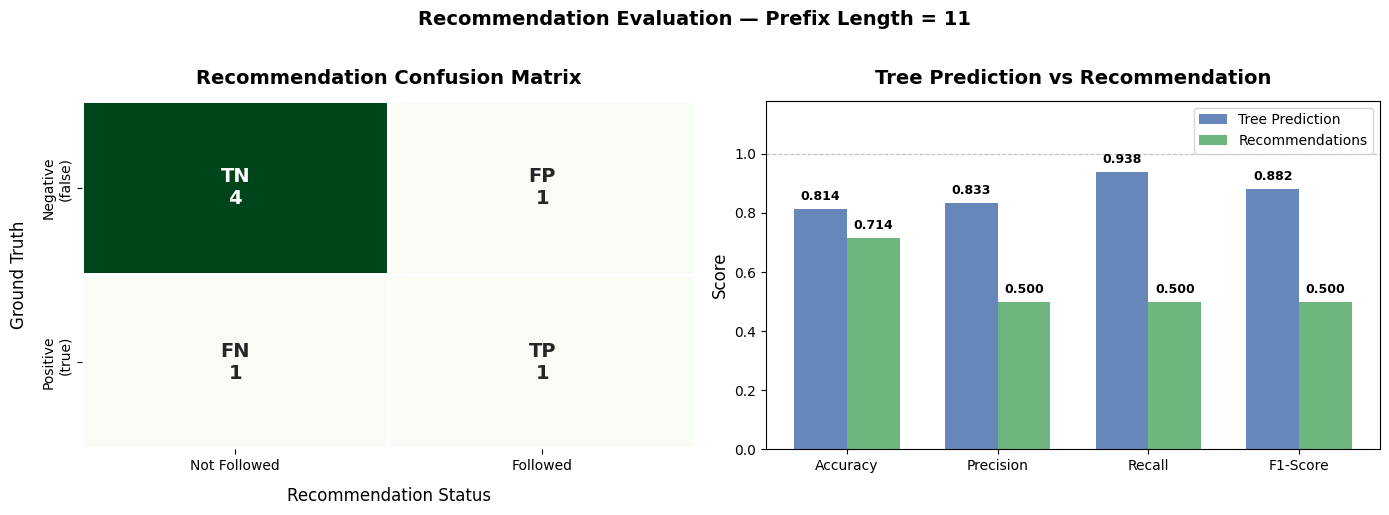

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Recommendation Confusion Matrix ──
rec_cm = np.array([[eval_results['tn'], eval_results['fp']],
                   [eval_results['fn'], eval_results['tp']]])
rec_annot = np.array([[f"TN\n{eval_results['tn']}", f"FP\n{eval_results['fp']}"],
                      [f"FN\n{eval_results['fn']}", f"TP\n{eval_results['tp']}"]])

sns.heatmap(
    rec_cm, ax=axes[0], annot=rec_annot, fmt='', cmap='Greens',
    xticklabels=['Not Followed', 'Followed'],
    yticklabels=['Negative\n(false)', 'Positive\n(true)'],
    linewidths=1.5, linecolor='white', cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_xlabel('Recommendation Status', fontsize=12, labelpad=10)
axes[0].set_ylabel('Ground Truth', fontsize=12, labelpad=10)
axes[0].set_title('Recommendation Confusion Matrix', fontsize=14, fontweight='bold', pad=12)

# ── Right: Tree Prediction vs Recommendation Metrics ──
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
tree_vals = [accuracy, precision, recall, f1]
rec_vals = [eval_results['accuracy'], eval_results['precision'],
            eval_results['recall'], eval_results['f1_score']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[1].bar(x - width/2, tree_vals, width, label='Tree Prediction',
                    color='#4C72B0', alpha=0.85)
bars2 = axes[1].bar(x + width/2, rec_vals, width, label='Recommendations',
                    color='#55A868', alpha=0.85)

axes[1].set_ylim(0, 1.18)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Tree Prediction vs Recommendation', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_names)
axes[1].legend(fontsize=10)
axes[1].axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.suptitle(f'Recommendation Evaluation — Prefix Length = {PREFIX_LENGTH}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# STEP 11: Visual Example on the Decision Tree
Selects a negatively predicted trace, traces its path through the tree, and renders an annotated Graphviz graph highlighting recommendation nodes (add = blue, remove = red).

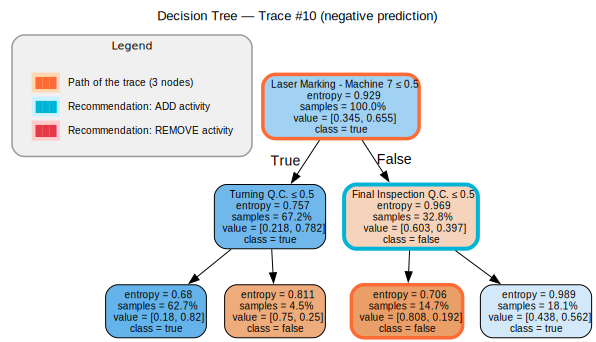

TRACE #10  —  Activities in prefix: 7

Path through the tree:
  1. Node 0: split on 'Laser Marking - Machine 7'
  2. Node 4: split on 'Final Inspection Q.C.' [REC]
  3. Node 5: LEAF -> class 'false'

Recommendations (1):
  - ADD: 'Final Inspection Q.C.'


In [31]:
from sklearn.tree import export_graphviz
from src.preprocessing import exclude_keys_from_trace
import graphviz, re, html

#  1. Select a negative trace with recommendations 
y_pred_all = clf.predict(X_test)
example_idx = None

for i in range(len(test_encoded)):
    if y_pred_all[i] != class_values[0]:  # negative prediction
        row = test_encoded.iloc[i]
        true_acts = exclude_keys_from_trace(row.to_dict())
        key = frozenset(true_acts.keys())
        if key in recommendations and recommendations[key] and len(recommendations[key]) > 0:
            example_idx = i
            example_activities = set(true_acts.keys())
            example_recs = recommendations[key]
            example_trace_features = {feat: row[feat] for feat in feature_names}
            break

if example_idx is None:
    print("No negative trace with recommendations found.")
else:
    #  2. Trace the path through the tree 
    tree_ = clf.tree_

    def trace_path(tree_, feature_names, trace_features):
        path, node = [], 0
        while tree_.feature[node] != -2:
            path.append(node)
            feat = feature_names[tree_.feature[node]]
            val = trace_features.get(feat, 0)
            node = tree_.children_left[node] if val <= tree_.threshold[node] else tree_.children_right[node]
        path.append(node)
        return path

    path_nodes = trace_path(tree_, feature_names, example_trace_features)
    recommended_features = {c.feature: c.value for c in example_recs}

    # Map tree nodes where a recommended feature is the split criterion
    rec_nodes = {}
    for nid in range(tree_.node_count):
        if tree_.feature[nid] != -2:
            fname = feature_names[tree_.feature[nid]]
            if fname in recommended_features:
                rec_nodes[nid] = (fname, recommended_features[fname])

    #  3. Render annotated decision tree 
    safe_names = [html.escape(n) for n in feature_names]
    dot_data = export_graphviz(
        clf, out_file=None, feature_names=safe_names,
        class_names=['false', 'true'], filled=True, rounded=True,
        special_characters=True, proportion=True
    )

    PATH_COLOR  = "#FF6B35"   # orange — trace path
    ADD_COLOR   = "#00B4D8"   # blue   — add activity
    REM_COLOR   = "#E63946"   # red    — remove activity

    new_lines = []
    for line in dot_data.split('\n'):
        m = re.match(r'^(\d+) \[(.*)$', line)
        if m:
            nid = int(m.group(1))
            rest = m.group(2)
            if nid in rec_nodes:
                col = ADD_COLOR if rec_nodes[nid][1] else REM_COLOR
                new_lines.append(f'{nid} [color="{col}", penwidth=4, style="bold,filled,rounded", {rest}')
            elif nid in path_nodes:
                new_lines.append(f'{nid} [color="{PATH_COLOR}", penwidth=3.5, style="bold,filled,rounded", {rest}')
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)

    modified_dot = '\n'.join(new_lines)

    legend = f'''digraph Tree {{
    label="Decision Tree — Trace #{example_idx} (negative prediction)";
    labelloc="t"; fontsize=13; fontname="Arial";

    subgraph cluster_legend {{
        label="Legend"; style="rounded,filled"; fillcolor="#F0F0F0";
        color="#999"; penwidth=1.5; fontsize=11; fontname="Arial Bold";
        node [shape=plaintext fontsize=10 fontname="Arial"];
        legend_table [label=<
            <TABLE BORDER="0" CELLSPACING="4" CELLPADDING="4">
                <TR><TD BGCOLOR="#FFD9B3"><FONT COLOR="{PATH_COLOR}">███</FONT></TD>
                    <TD ALIGN="LEFT">Path of the trace ({len(path_nodes)} nodes)</TD></TR>
                <TR><TD BGCOLOR="#CCF2FF"><FONT COLOR="{ADD_COLOR}">███</FONT></TD>
                    <TD ALIGN="LEFT">Recommendation: ADD activity</TD></TR>
                <TR><TD BGCOLOR="#FFCCCC"><FONT COLOR="{REM_COLOR}">███</FONT></TD>
                    <TD ALIGN="LEFT">Recommendation: REMOVE activity</TD></TR>
            </TABLE>
        >];
    }}
    node [fontsize=10];
'''
    modified_dot = modified_dot.replace('digraph Tree {', legend)

    graph = graphviz.Source(modified_dot, format='svg')
    display(graph)

    #  4. Textual summary 
    print(f"TRACE #{example_idx}  —  Activities in prefix: {len(example_activities)}")
    print("\nPath through the tree:")
    for j, nid in enumerate(path_nodes, 1):
        if tree_.feature[nid] != -2:
            fn = feature_names[tree_.feature[nid]]
            tag = " [REC]" if nid in rec_nodes else ""
            print(f"  {j}. Node {nid}: split on '{fn}'{tag}")
        else:
            lc = 'true' if tree_.value[nid][0][1] > tree_.value[nid][0][0] else 'false'
            print(f"  {j}. Node {nid}: LEAF -> class '{lc}'")

    print(f"\nRecommendations ({len(example_recs)}):")
    for c in example_recs:
        act = "ADD" if c.value else "REMOVE"
        print(f"  - {act}: '{c.feature}'")

# STEP 12: Prefix Length Comparison
Runs the full pipeline for prefix lengths 5 and 11, comparing prediction and recommendation metrics side by side to show how available prefix information affects quality.

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score as f1_score_fn

prefix_lengths_to_test = [5, 11]
comparison_results = {}

for pl in prefix_lengths_to_test:
    print(f"  PREFIX LENGTH = {pl}")

    # 1. Create prefixes
    train_pref = create_prefixes_log(train_log, pl, use_padding=True)
    test_pref  = create_prefixes_log(test_log, pl, use_padding=True)

    # 2. Boolean encode
    train_enc = boolean_encode(train_pref, activity_names)
    test_enc  = boolean_encode(test_pref, activity_names)

    # 3. Prepare data  (prefix_length excluded from features)
    feat_names = [c for c in train_enc.columns
                  if c not in ['trace_id', 'label', 'prefix_length']]
    X_tr = train_enc[feat_names]
    y_tr = train_enc['label']
    X_te = test_enc[feat_names]
    y_te = test_enc['label']

    # 4. Hyperparameter optimisation (GridSearchCV)
    grid = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        cv=5, scoring=f1_true_scorer,
        n_jobs=-1, verbose=0
    )
    grid.fit(X_tr, y_tr)
    best_params = {**grid.best_params_, 'random_state': 42}
    print(f"  Best params: {grid.best_params_}")

    # 5. Train and predict
    dt = DecisionTreeClassifier(**best_params)
    dt.fit(X_tr, y_tr)
    preds = dt.predict(X_te)

    # 6. Tree prediction metrics
    t_acc  = accuracy_score(y_te, preds)
    t_prec = precision_score(y_te, preds, pos_label='true')
    t_rec  = recall_score(y_te, preds, pos_label='true')
    t_f1   = f1_score_fn(y_te, preds, pos_label='true')
    print(f"  Tree  → Acc={t_acc:.4f}  Prec={t_prec:.4f}  Rec={t_rec:.4f}  F1={t_f1:.4f}")

    # 7. Extract recommendations
    recs = extract_recommendations(dt, feat_names, class_values, test_enc)

    # 8. Evaluate recommendations against full traces
    full_enc = boolean_encode(test_log, activity_names)
    ts = {'tree': dt, 'feature_names': feat_names, 'class_values': class_values,
          'prefix_test_set': test_enc, 'full_test_set': full_enc}
    ev = evaluate_recommendations(ts, recs)
    print(f"  Recs  → Acc={ev['accuracy']:.4f}  Prec={ev['precision']:.4f}  "
          f"Rec={ev['recall']:.4f}  F1={ev['f1_score']:.4f}")
    print(f"  (TP={ev['tp']} TN={ev['tn']} FP={ev['fp']} FN={ev['fn']}  evaluated={ev['evaluated']})")

    comparison_results[pl] = {
        'tree_accuracy': t_acc, 'tree_precision': t_prec,
        'tree_recall': t_rec, 'tree_f1': t_f1,
        'rec_accuracy': ev['accuracy'], 'rec_precision': ev['precision'],
        'rec_recall': ev['recall'], 'rec_f1': ev['f1_score'],

        'best_params': best_params, 'eval_details': ev,    }

  PREFIX LENGTH = 5
  Best params: {'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
  Tree  → Acc=0.7442  Prec=0.7442  Rec=1.0000  F1=0.8533
Found 3 positive paths in the tree

Summary:
  - Traces with positive prediction: 43
  - Traces with recommendations: 0
  - Negative traces without possible recommendations: 0
  Recs  → Acc=0.0000  Prec=0.0000  Rec=0.0000  F1=0.0000
  (TP=0 TN=0 FP=0 FN=0  evaluated=0)
  PREFIX LENGTH = 11
  Best params: {'criterion': 'entropy', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Tree  → Acc=0.8140  Prec=0.8333  Rec=0.9375  F1=0.8824
Found 2 positive paths in the tree

Summary:
  - Traces with positive prediction: 36
  - Traces with recommendations: 7
  - Negative traces without possible recommendations: 0
  Recs  → Acc=0.7143  Prec=0.5000  Rec=0.5000  F1=0.5000
  (TP=1 TN=4 FP=1 FN=1  evaluated=7)


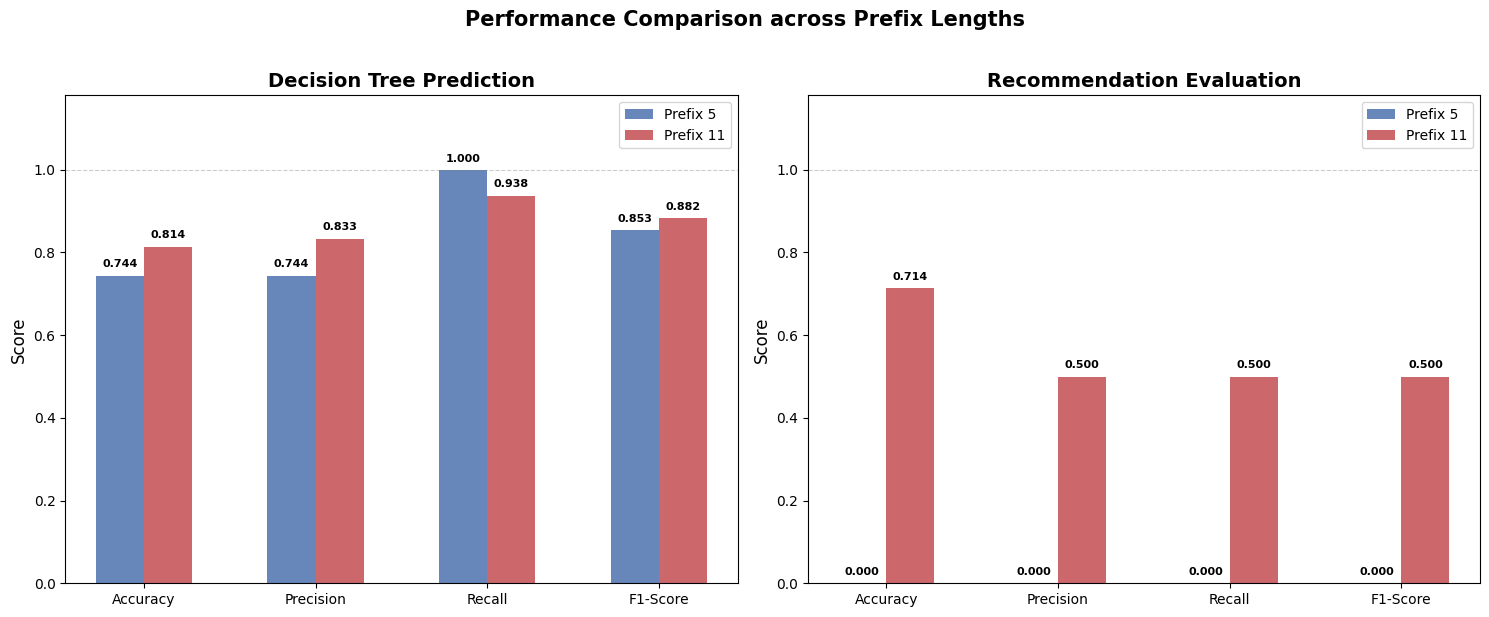

  Prefix │   Tree Acc    Tree F1 │    Rec Acc     Rec F1
       5 │     0.7442     0.8533 │     0.0000     0.0000
      11 │     0.8140     0.8824 │     0.7143     0.5000


In [34]:
import matplotlib.pyplot as plt
import numpy as np

pls = list(comparison_results.keys())
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(metrics_labels))
width = 0.28
colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']

#  Left: Decision Tree performance 
tree_keys = ['tree_accuracy', 'tree_precision', 'tree_recall', 'tree_f1']
for i, pl in enumerate(pls):
    vals = [comparison_results[pl][k] for k in tree_keys]
    offset = (i - (len(pls)-1)/2) * width
    bars = axes[0].bar(x + offset, vals, width, label=f'Prefix {pl}',
                       color=colors[i], alpha=0.85)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                    f'{bar.get_height():.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
axes[0].set_ylim(0, 1.18)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Decision Tree Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)

#  Right: Recommendation performance 
rec_keys = ['rec_accuracy', 'rec_precision', 'rec_recall', 'rec_f1']
for i, pl in enumerate(pls):
    vals = [comparison_results[pl][k] for k in rec_keys]
    offset = (i - (len(pls)-1)/2) * width
    bars = axes[1].bar(x + offset, vals, width, label=f'Prefix {pl}',
                       color=colors[i], alpha=0.85)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                    f'{bar.get_height():.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
axes[1].set_ylim(0, 1.18)
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics_labels)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Recommendation Evaluation', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)

plt.suptitle('Performance Comparison across Prefix Lengths',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Summary table 
print(f"{'Prefix':>8} │ {'Tree Acc':>10} {'Tree F1':>10} │ {'Rec Acc':>10} {'Rec F1':>10}")
for pl in pls:
    r = comparison_results[pl]
    print(f"{pl:>8} │ {r['tree_accuracy']:>10.4f} {r['tree_f1']:>10.4f} │ "
          f"{r['rec_accuracy']:>10.4f} {r['rec_f1']:>10.4f}")

# STEP 12b: Comprehensive Prefix Length Analysis (1–12)
Runs the full pipeline for every prefix length from 1 to 12 and plots F1-score trends for both prediction and recommendation quality.

In [35]:
# Comprehensive prefix length analysis: prefix lengths 1–12

prefix_range = range(1, 13)  # 1 to 12
full_comparison = {}

for pl in prefix_range:
    print(f"Prefix {pl:>2d} ... ", end="", flush=True)

    # 1. Create prefixes with padding
    tr_pref = create_prefixes_log(train_log, pl, use_padding=True)
    te_pref = create_prefixes_log(test_log,  pl, use_padding=True)

    # 2. Boolean encode
    tr_enc = boolean_encode(tr_pref, activity_names)
    te_enc = boolean_encode(te_pref, activity_names)

    # 3. Prepare features (exclude prefix_length, trace_id, label)
    feat = [c for c in tr_enc.columns if c not in ['trace_id', 'label', 'prefix_length']]
    X_tr = tr_enc[feat]
    y_tr = tr_enc['label']
    X_te = te_enc[feat]
    y_te = te_enc['label']

    # 4. Hyperparameter optimisation (GridSearchCV)
    grid = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        cv=5, scoring=f1_true_scorer,
        n_jobs=-1, verbose=0
    )
    grid.fit(X_tr, y_tr)
    best_p = {**grid.best_params_, 'random_state': 42}

    # 5. Train and predict
    dt = DecisionTreeClassifier(**best_p)
    dt.fit(X_tr, y_tr)
    preds = dt.predict(X_te)

    # 6. Tree prediction metrics
    t_acc  = accuracy_score(y_te, preds)
    t_prec = precision_score(y_te, preds, pos_label='true', zero_division=0)
    t_rec  = recall_score(y_te, preds, pos_label='true', zero_division=0)
    t_f1   = f1_score_fn(y_te, preds, pos_label='true', zero_division=0)

    # 7. Recommendations
    recs = extract_recommendations(dt, feat, class_values, te_enc)

    # 8. Evaluate recommendations against full traces
    full_enc = boolean_encode(test_log, activity_names)
    ts = {'tree': dt, 'feature_names': feat, 'class_values': class_values,
          'prefix_test_set': te_enc, 'full_test_set': full_enc}
    ev = evaluate_recommendations(ts, recs)

    full_comparison[pl] = {
        'tree_accuracy': t_acc, 'tree_precision': t_prec,
        'tree_recall': t_rec, 'tree_f1': t_f1,
        'rec_accuracy': ev['accuracy'], 'rec_precision': ev['precision'],
        'rec_recall': ev['recall'], 'rec_f1': ev['f1_score'],
        'best_params': best_p, 'eval_details': ev,
        'n_negative_preds': ev['evaluated'],
    }
    print(f"Tree F1={t_f1:.3f}  Rec F1={ev['f1_score']:.3f}  (neg preds: {ev['evaluated']})")

print("\nFull comparison complete.")

Prefix  1 ... Found 2 positive paths in the tree

Summary:
  - Traces with positive prediction: 43
  - Traces with recommendations: 0
  - Negative traces without possible recommendations: 0
Tree F1=0.853  Rec F1=0.000  (neg preds: 0)
Prefix  2 ... Found 2 positive paths in the tree

Summary:
  - Traces with positive prediction: 41
  - Traces with recommendations: 0
  - Negative traces without possible recommendations: 2
Tree F1=0.849  Rec F1=0.000  (neg preds: 2)
Prefix  3 ... Found 3 positive paths in the tree

Summary:
  - Traces with positive prediction: 43
  - Traces with recommendations: 0
  - Negative traces without possible recommendations: 0
Tree F1=0.853  Rec F1=0.000  (neg preds: 0)
Prefix  4 ... Found 3 positive paths in the tree

Summary:
  - Traces with positive prediction: 43
  - Traces with recommendations: 0
  - Negative traces without possible recommendations: 0
Tree F1=0.853  Rec F1=0.000  (neg preds: 0)
Prefix  5 ... Found 3 positive paths in the tree

Summary:
  - T

prefix_f1_comparison.pdf saved


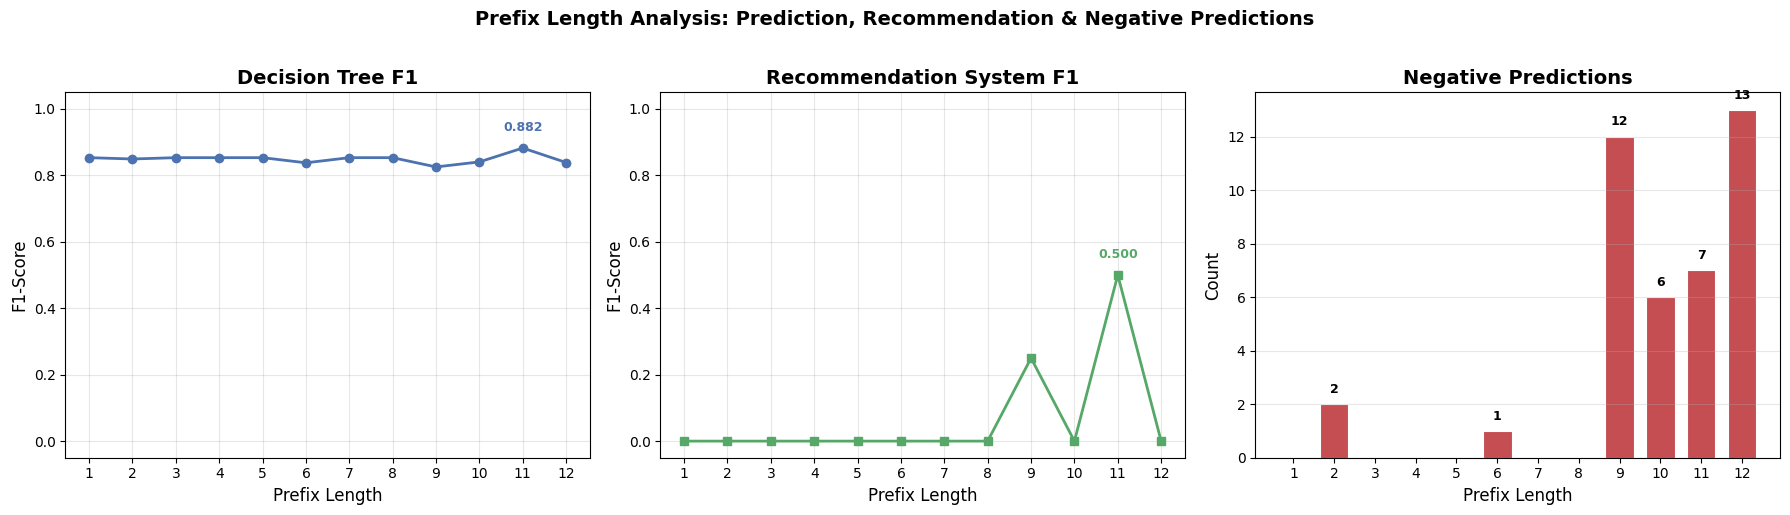


  Prefix │    Tree F1   Tree Acc │     Rec F1    Rec Acc │  Neg Preds
────────────────────────────────────────────────────────────────────────────────
       1 │      0.853      0.744 │      0.000      0.000 │          0
       2 │      0.849      0.744 │      0.000      0.500 │          2
       3 │      0.853      0.744 │      0.000      0.000 │          0
       4 │      0.853      0.744 │      0.000      0.000 │          0
       5 │      0.853      0.744 │      0.000      0.000 │          0
       6 │      0.838      0.721 │      0.000      0.000 │          1
       7 │      0.853      0.744 │      0.000      0.000 │          0
       8 │      0.853      0.744 │      0.000      0.000 │          0
       9 │      0.825      0.744 │      0.250      0.500 │         12
      10 │      0.841      0.744 │      0.000      0.500 │          6
      11 │      0.882      0.814 │      0.500      0.714 │          7
      12 │      0.839      0.767 │      0.000      0.538 │         13
────────

In [36]:
# Three-panel figure: Tree F1 | Rec F1 | Negative Predictions

import matplotlib.pyplot as plt
import numpy as np
import os

pls = sorted(full_comparison.keys())
tree_f1s = [full_comparison[pl]['tree_f1'] for pl in pls]
rec_f1s  = [full_comparison[pl]['rec_f1']  for pl in pls]
neg_preds = [full_comparison[pl]['n_negative_preds'] for pl in pls]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#  Left: Decision Tree F1 
ax1.plot(pls, tree_f1s, marker='o', color='#4C72B0', linewidth=2, markersize=6)
ax1.set_xlabel('Prefix Length', fontsize=12)
ax1.set_ylabel('F1-Score', fontsize=12)
ax1.set_title('Decision Tree F1', fontsize=14, fontweight='bold')
ax1.set_xticks(pls)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
# Highlight best
best_tree_idx = int(np.argmax(tree_f1s))
ax1.annotate(f'{tree_f1s[best_tree_idx]:.3f}',
             xy=(pls[best_tree_idx], tree_f1s[best_tree_idx]),
             xytext=(0, 12), textcoords='offset points',
             ha='center', fontsize=9, fontweight='bold', color='#4C72B0')

#  Center: Recommendation F1 
ax2.plot(pls, rec_f1s, marker='s', color='#55A868', linewidth=2, markersize=6)
ax2.set_xlabel('Prefix Length', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('Recommendation System F1', fontsize=14, fontweight='bold')
ax2.set_xticks(pls)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)
# Highlight best
best_rec_idx = int(np.argmax(rec_f1s))
if rec_f1s[best_rec_idx] > 0:
    ax2.annotate(f'{rec_f1s[best_rec_idx]:.3f}',
                 xy=(pls[best_rec_idx], rec_f1s[best_rec_idx]),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold', color='#55A868')

#  Right: Number of Negative Predictions 
colors_bar = ['#C44E52' if n > 0 else '#CCCCCC' for n in neg_preds]
bars = ax3.bar(pls, neg_preds, color=colors_bar, width=0.7, edgecolor='white', linewidth=0.8)
ax3.set_xlabel('Prefix Length', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Negative Predictions', fontsize=14, fontweight='bold')
ax3.set_xticks(pls)
ax3.grid(True, alpha=0.3, axis='y')
# Add count labels on bars
for bar, n in zip(bars, neg_preds):
    if n > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(n), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Prefix Length Analysis: Prediction, Recommendation & Negative Predictions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure for the LaTeX report
FIGURES_DIR = os.path.abspath("../LaTeXTemplates_diaz-essay_v2/figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURES_DIR, "prefix_f1_comparison.pdf"), bbox_inches='tight', dpi=300)
print("prefix_f1_comparison.pdf saved")

plt.show()

#  Summary table 
print(f"\n{'Prefix':>8} │ {'Tree F1':>10} {'Tree Acc':>10} │ {'Rec F1':>10} {'Rec Acc':>10} │ {'Neg Preds':>10}")
print("─" * 80)
for pl in pls:
    r = full_comparison[pl]
    print(f"{pl:>8} │ {r['tree_f1']:>10.3f} {r['tree_accuracy']:>10.3f} │ "
          f"{r['rec_f1']:>10.3f} {r['rec_accuracy']:>10.3f} │ {r['n_negative_preds']:>10}")
print("─" * 80)

# Conclusion
### Pipeline Overview

| Step | Description |
|------|-------------|
| 0    | **Import libraries** |
| 1    | **Load training & test XES logs** |
| 2    | **Generate prefix traces** (with padding) |
| 3    | **Extract unique activity names** |
| 4    | **Boolean encoding of prefixes** |
| 5    | **Train Decision Tree** with GridSearchCV hyperparameter optimisation |
| 6    | **Evaluate model** (accuracy, precision, recall, F1, confusion matrix) |
| 7    | **Extract recommendations** for negatively predicted traces |
| 8–9  | **Analyse recommendations** and inspect results |
| 10   | **Evaluate recommendations** against full traces (TP/TN/FP/FN) |
| 11   | **Visual example** — highlight recommendation path on the tree |
| 12   | **Compare prefix lengths** — prediction & recommendation metrics |

### Key Functions

| Function | Purpose |
|----------|---------|
| `get_positive_paths()` | DFS to extract all positive-leaf paths from the tree |
| `get_compliant_paths()` | Filter paths compatible with the trace's current state |
| `get_missing_conditions()` | Compute which conditions the trace still needs to satisfy |
| `extract_recommendations()` | Orchestrate the full recommendation pipeline |
| `evaluate_recommendations()` | Check if recommendations match the ground-truth full traces |